In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
data = pd.read_csv(r"../Data/datasets_formatted.csv")
trimmed = pd.read_csv(r"../Data/dropout_clean_trimmed.csv")
data = data[trimmed.columns]
data = data.drop(columns = "Entry Year")
print(data.shape)

(464739, 11)


In [61]:
from sklearn.model_selection import train_test_split

X = data22.drop(columns="Dropout (1=Yes 0=No)")
y = data22["Dropout (1=Yes 0=No)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,          # reproducible
    stratify=y                # keeps dropout ratio equal in both splits
)

clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}

In [62]:
clf_grid = GridSearchCV(clf, param_grid)

In [ ]:
clf_grid.fit(X_train, y_train) 

In [ ]:
path = clf.cost_complexity_pruning_path(X_train, y_train)

param_grid = {'ccp_alpha': path['ccp_alphas']}

clf_grid = GridSearchCV(clf, param_grid)

clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

In [ ]:
columns = data22.columns.drop("Dropout (1=Yes 0=No)")

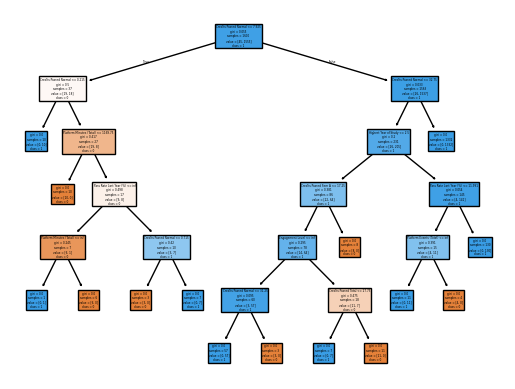

In [ ]:
tree.plot_tree(clf_grid.best_estimator_, feature_names=columns, class_names = ["0", "1"], filled = True)
# Source - https://stackoverflow.com/a/39870740
# Posted by Ohad Eytan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-24, License - CC BY-SA 4.0

plt.savefig('../Figures/BestTreeTrimmed.png', dpi=1500)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00       389

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

[[ 11   0]
 [  0 389]]
